In [2]:
from xmitgcm import open_mdsdataset
import xmitgcm 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib
import xarray as xr
import cmocean
import pylab as pl

import MITgcmutils
import math
import netCDF4 as nc
import scipy as sc
import scipy.io as sio
import scipy.interpolate as sciint
import warnings
import datetime
warnings.filterwarnings("ignore")

In [3]:
project='Sponge'
ed='run13/'

location='/Users/ameliaking/Proyecto/Codigo/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')

#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)-17
nx=len(ds.X)-2 
nz=len(ds.Zmd000010)

In [4]:
varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

In [5]:
varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')



In [ ]:
Psurface=-g*ETAN

In [14]:
-10*(ds.Zmd000010*-60 -30) + ds.PHIHYD[10,:,40,20] (m/s)^2

<xarray.DataArray (Zmd000010: 10)>
array([ 299.90637325,  899.7689662 , 1499.72095713, 2099.70830324,
       2699.70691457, 3299.70830694, 3899.71037993, 4499.71265188,
       5099.71509576, 5699.71787944])
Coordinates:
    X        float64 5.125e+04
    Y        float64 2.025e+05
    T        float64 1.063e+08
Dimensions without coordinates: Zmd000010

In [8]:
ds.Zld000010*-60

get RC to analyse if its negative becasue total pressure=-g*RC +PHIHYD 

Ptot=Phihyd + Psurface + PhiNoHyd


<xarray.DataArray 'Zld000010' (Zld000010: 10)>
array([   0,  -60, -120, -180, -240, -300, -360, -420, -480, -540])
Dimensions without coordinates: Zld000010

In [40]:
list(ds.keys())[7:]

['Um_Cori',
 'Um_dPhiX',
 'Um_Advec',
 'Um_Diss',
 'Um_AdvRe',
 'Vm_dPhiY',
 'USidDrag',
 'Um_ImplD',
 'Um_Ext',
 'Um_AdvZ3',
 'Vm_Cori',
 'Vm_Advec',
 'Vm_Diss',
 'Vm_AdvRe',
 'VSidDrag',
 'Vm_ImplD',
 'Vm_Ext',
 'Vm_AdvZ3']

# Momentum Equation in MITgcm

[du/dt] = - gravity * ( ETAN(i) - ETAN(i-1) ) / DXC

        + Um_dPHdx
        + Um_Advec   (+ Um_Cori : but only if using CD-Scheme )
        + Um_Diss    (+ Implicit vertical viscosity tendency)
        + Um_Ext
        + AB_gU

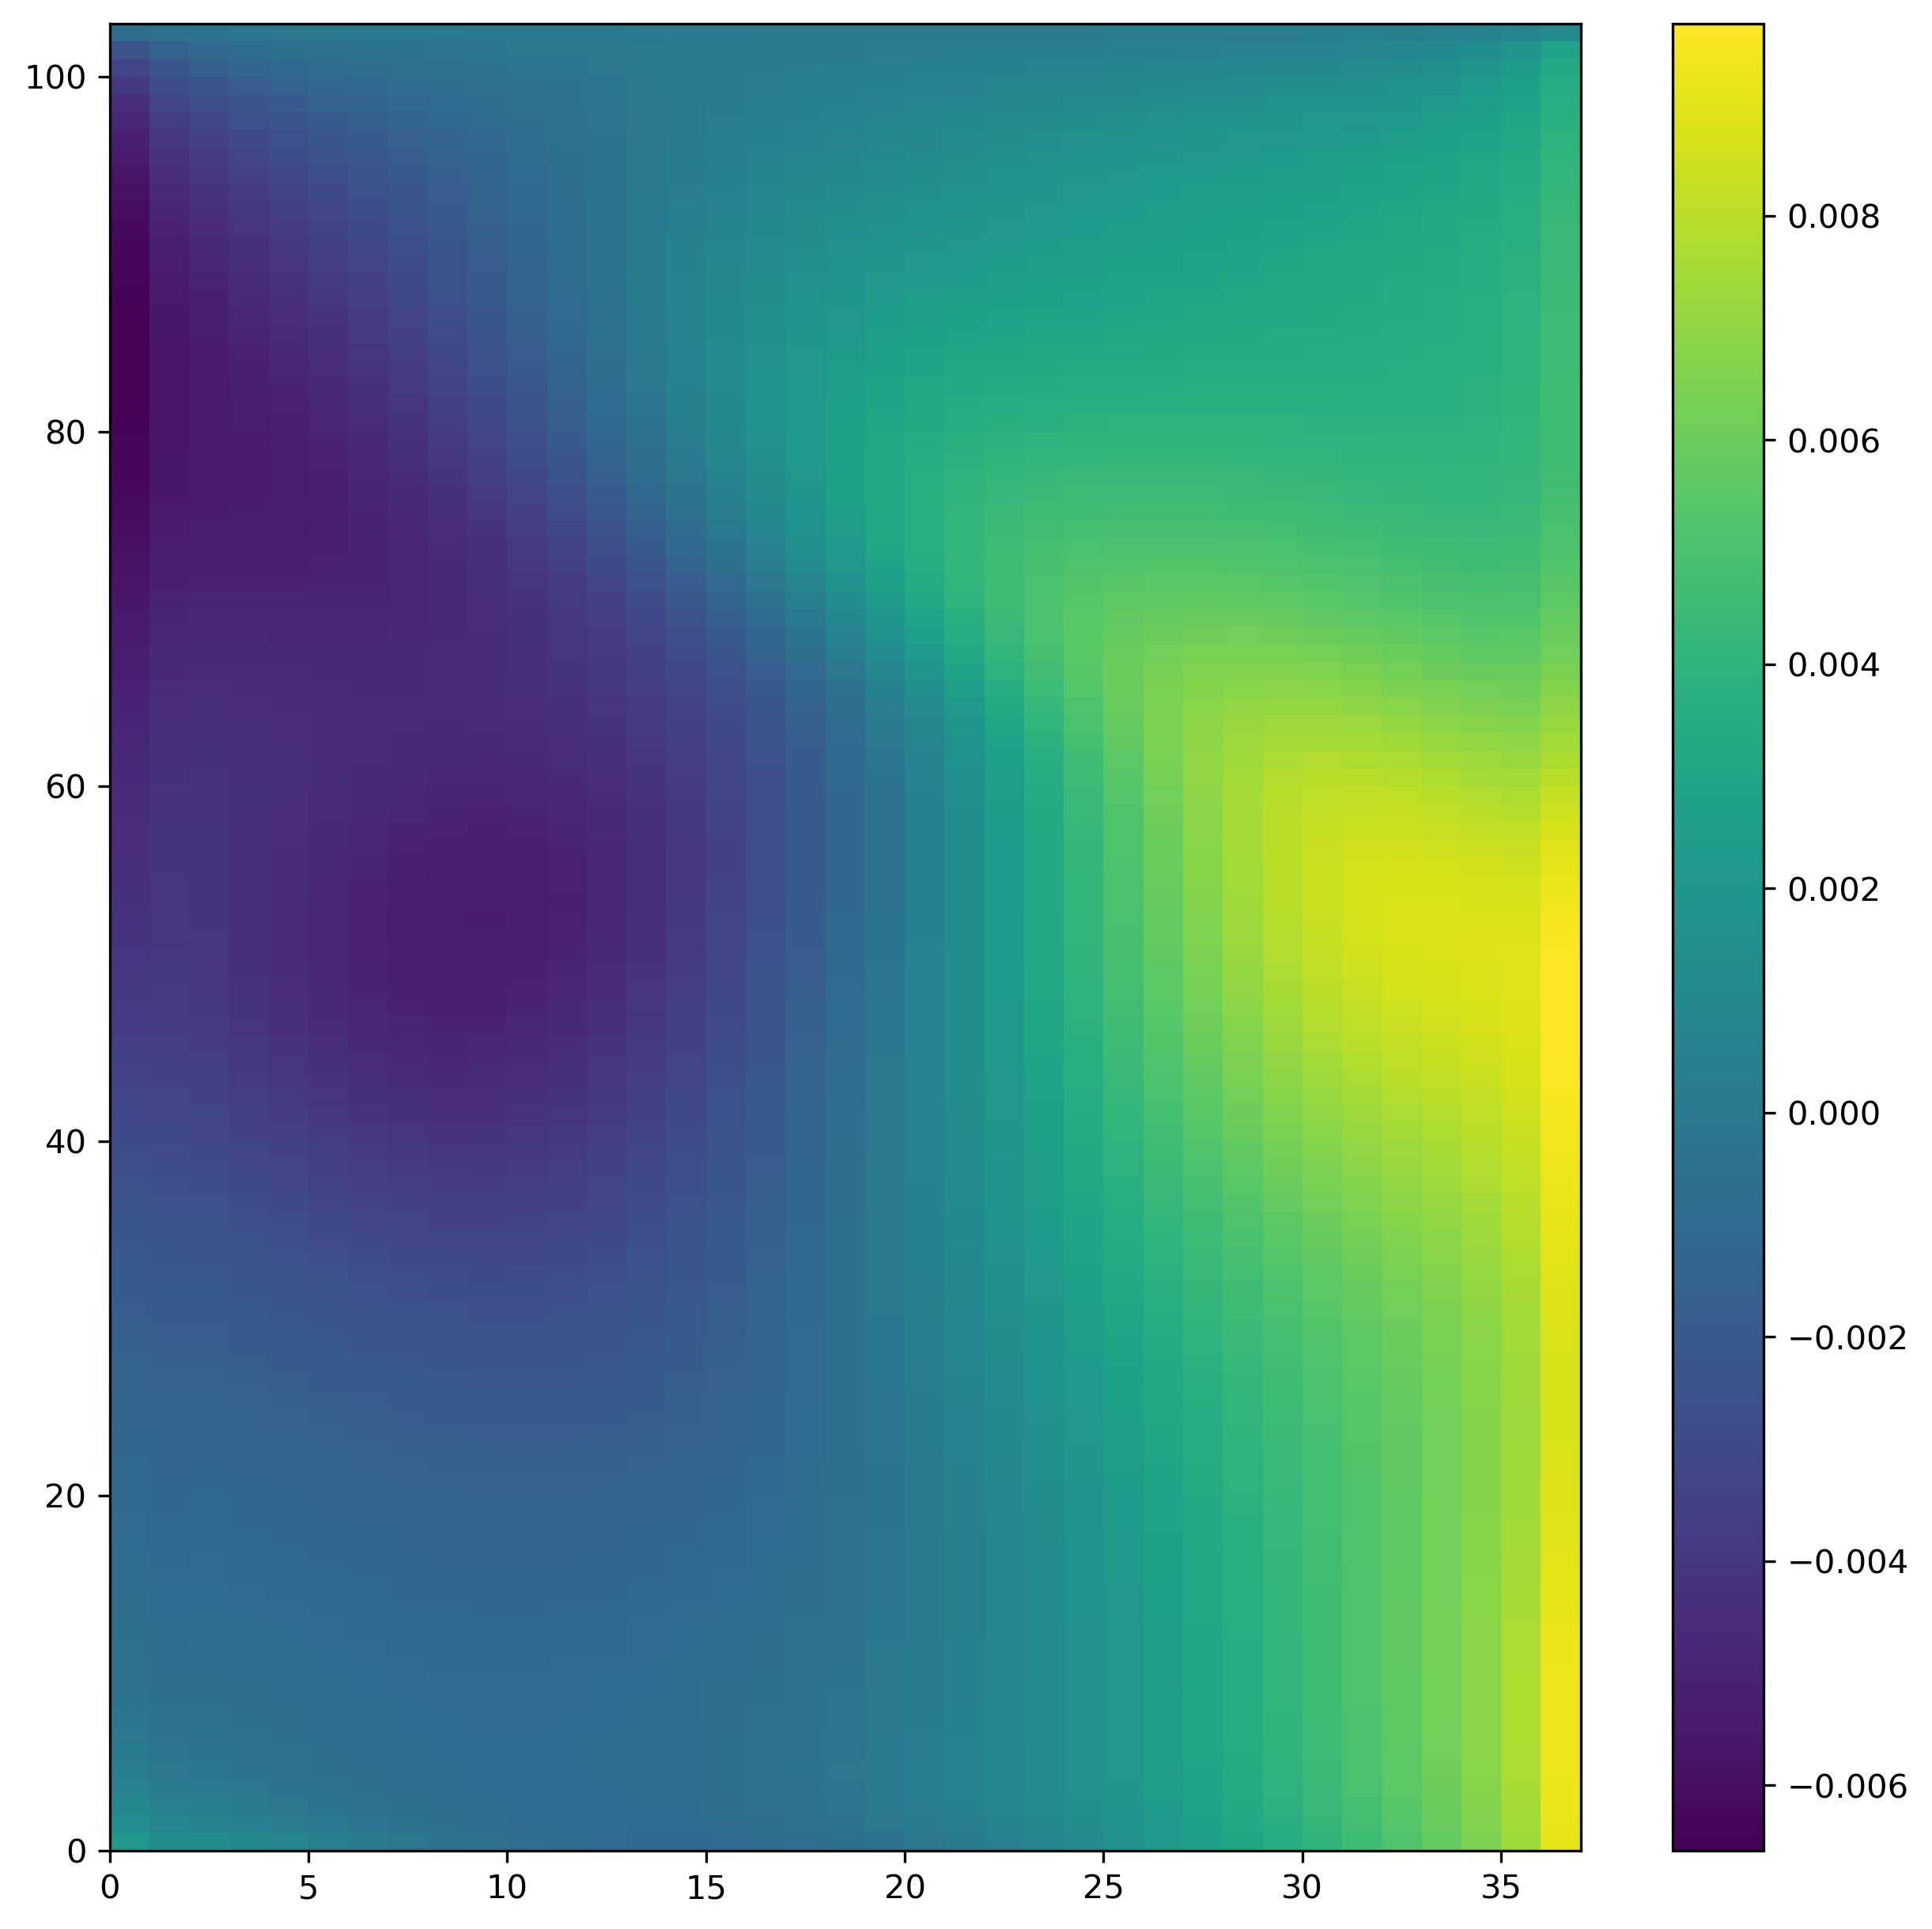

In [185]:
plt.pcolormesh(np.mean(np.mean(dPEtaX[6:,:,16:-1,1:-1],axis=0),axis=0))
plt.colorbar()


In [64]:
np.shape(((dsS.ETAN[:,0,1:,1:].values-dsS.ETAN[:,0,:-1,:-1].values)*9.8)/(dsG.dxC.values[0,0]*dsG.dyC.values[0,0]))

(119, 39)

In [6]:
dPEtaX=-((dsS.ETAN[30:,:,:,1:].values-dsS.ETAN[30:,:,:,:-1].values)*9.8)/(dsG.dxC.values[None,None,:,1:-1])
dPEtaY=-((dsS.ETAN[30:,:,1:,:].values-dsS.ETAN[30:,:,:-1,:].values)*9.8)/(dsG.dyC.values[None,None,1:-1,:])



In [59]:
dPtot=np.mean(np.mean(np.append(dPEtaX[6:],ds.Um_dPhiX[6:,:,:,1:-1].values,axis=1)[6:,:,16:-1,:],axis=0),axis=0)
RH=np.mean(np.mean(ds.Um_Advec[6:,:,16:-1:,1:-1],axis=0),axis=0)
LH=np.mean(np.mean(ds.Um_Diss[6:,:,16:-1,1:-1],axis=0),axis=0) + dPtot

In [63]:
dPtotv=np.mean(np.mean(np.append(dPEtaY[6:],ds.Vm_dPhiY[6:,:,1:-1,:].values,axis=1)[6:,:,16:,1:-1],axis=0),axis=0)
RHv=np.mean(np.mean(ds.Vm_Advec[6:,:,16:-1,1:-1],axis=0),axis=0)
LHv=np.mean(np.mean(ds.Vm_Diss[6:,:,16:-2,1:-1],axis=0),axis=0) + dPtotv

In [41]:
terminos=np.mean(np.mean(ds.Um_Diss[:,:,:,1:-1],axis=0),axis=0) + np.mean(np.mean(ds.Um_Advec[:,:,:,1:-1],axis=0),axis=0)+np.mean(np.append(np.mean(dPEtaX[6:],axis=0),np.mean(ds.Um_dPhiX[6:,:,:,1:-1].values,axis=0),axis=0),axis=0)


After heating: 15,16,17 
Before heating: 6,7,8 
During heating: 11,12,13

In [7]:
AH=[15,16,17,15+12,16+12,17+12]
BH=[6,7,8,6+12,7+12,8+12]
DH=[11,12,13,11+12,12+12,13+12]

times=[BH,DH,AH]

titles=['Month 1-3\nBefore heating','Month 6-8\nDuring heating','Month 10-12\nAfter heating']

In [8]:
def interpolating(Y,X,yin,xin,var):
    gridY,gridX=np.meshgrid(Y[2:-2].values,X[2:-2].values)

    interp=sciint.RegularGridInterpolator(yin,xin,var)
    varout=interp((gridY,gridX))
    
    return varout

In [9]:
params = {'font.size': 10,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

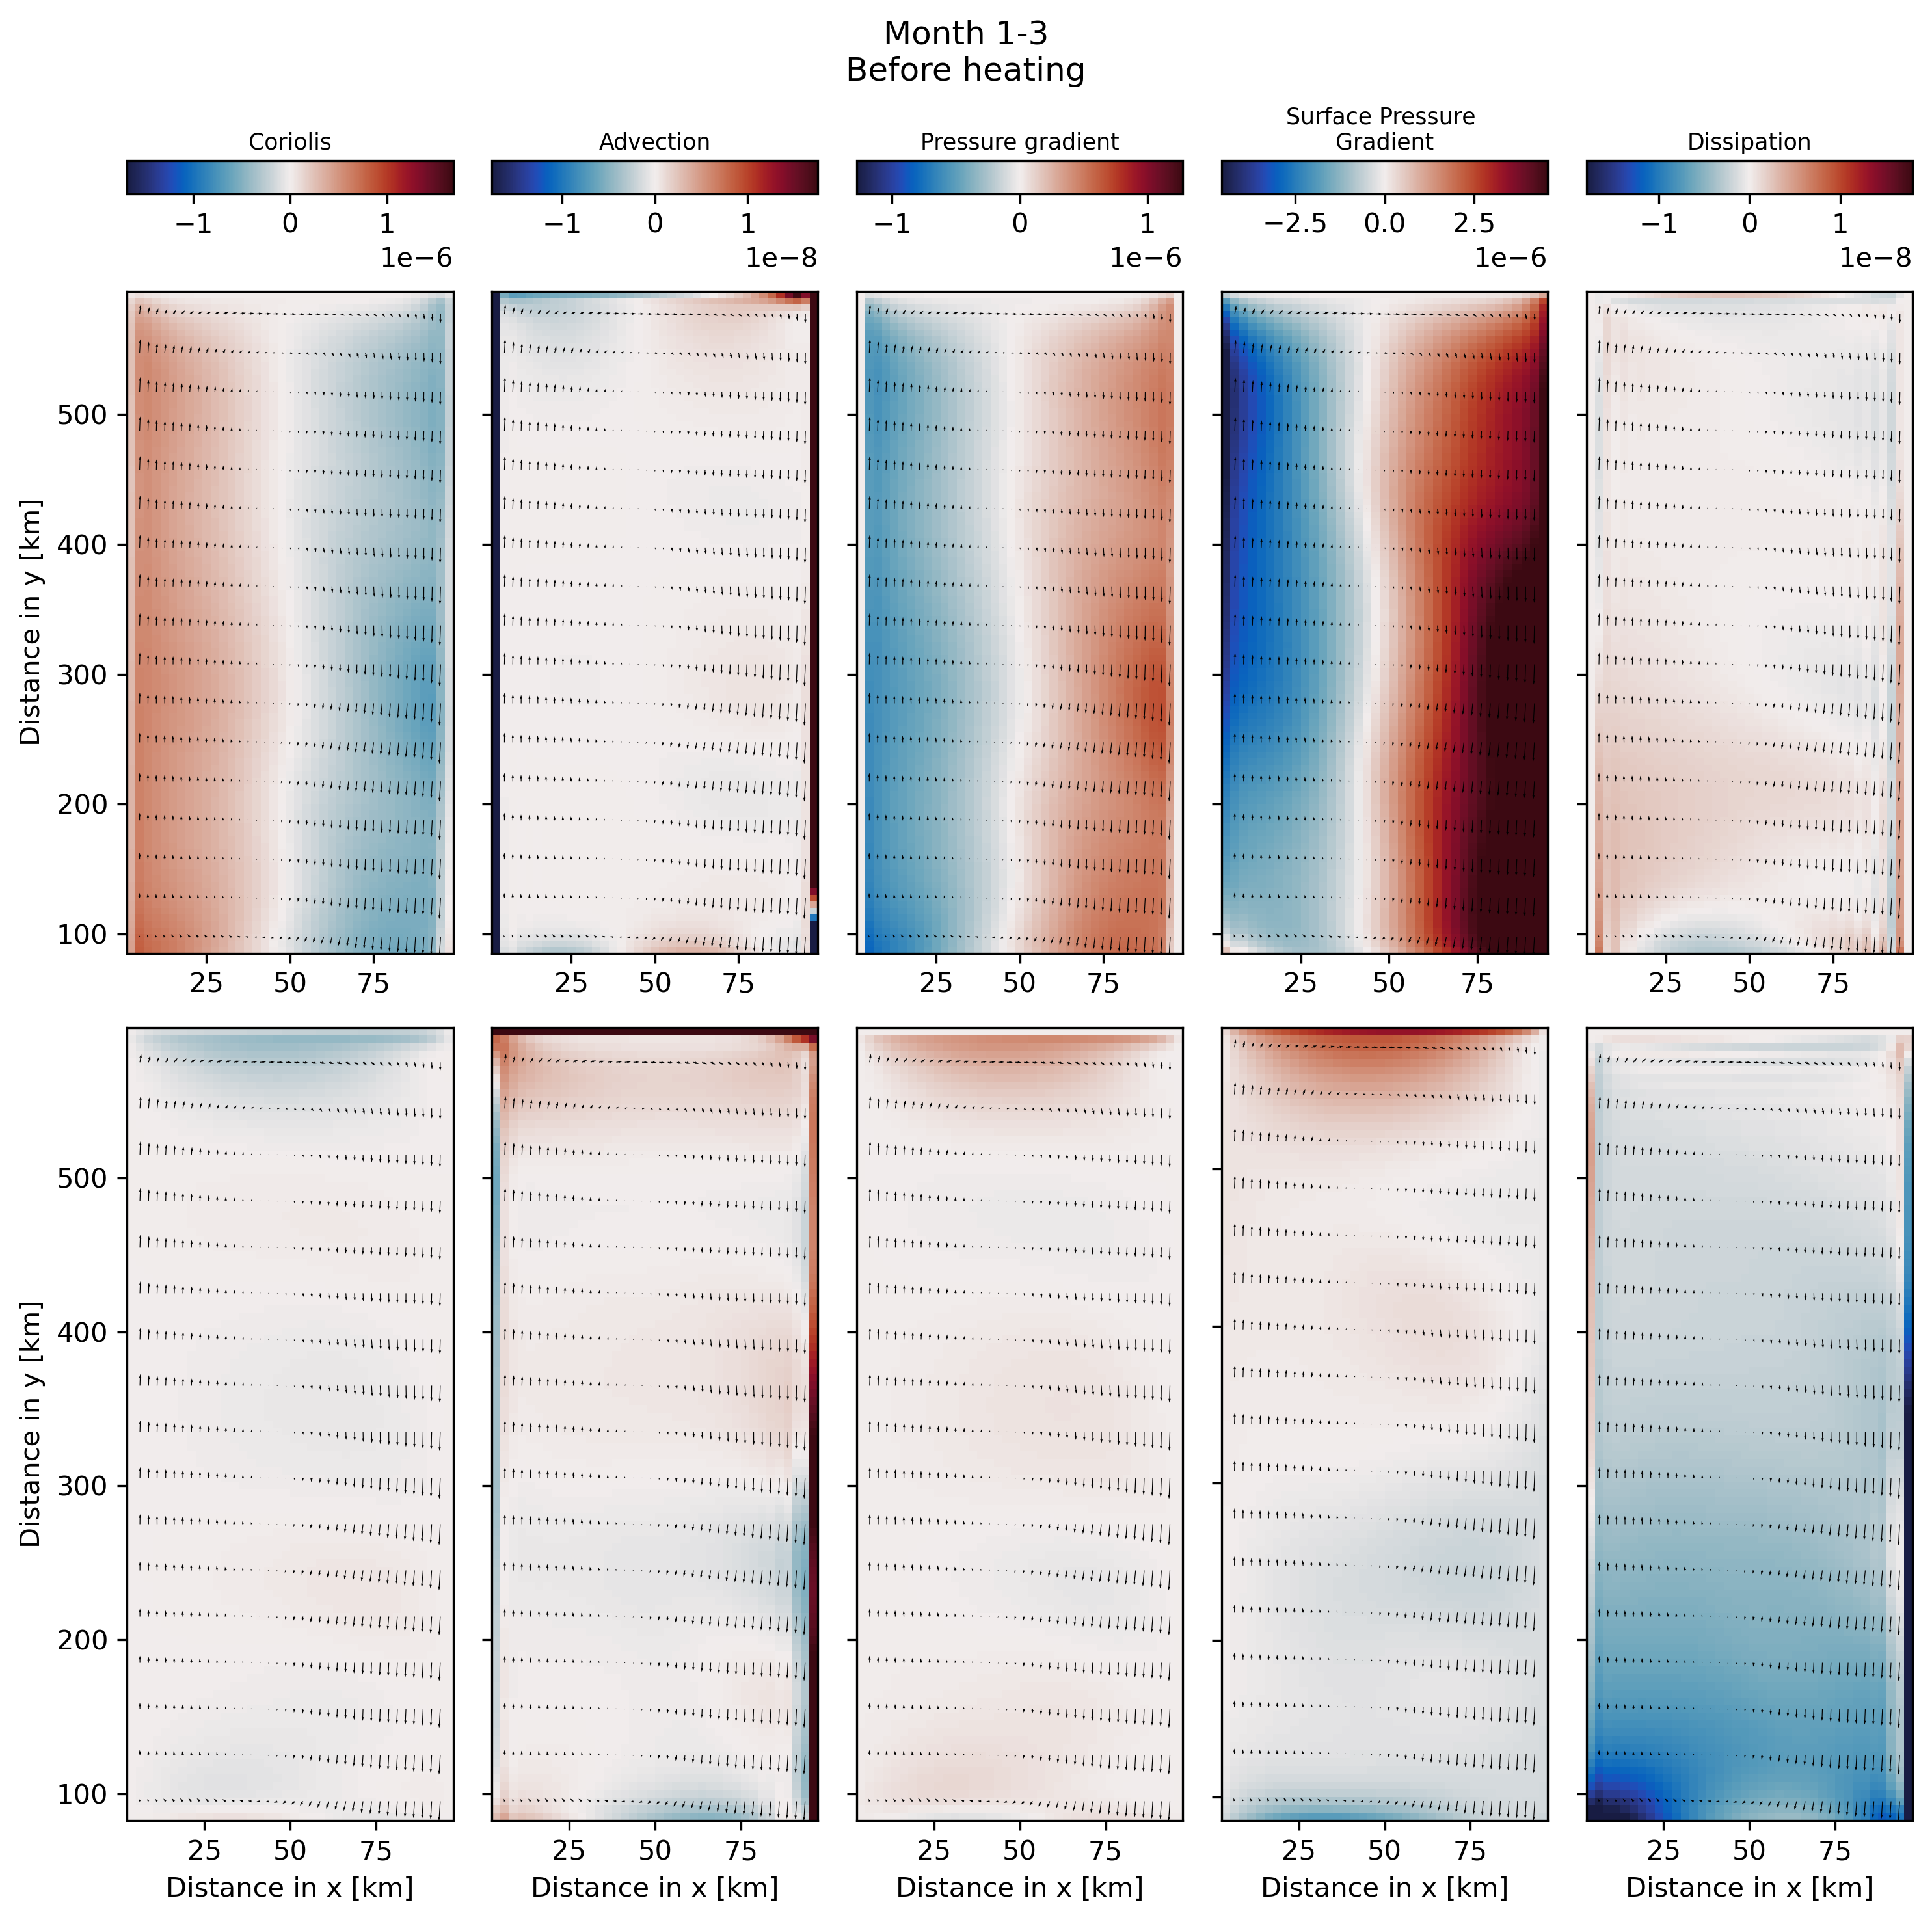

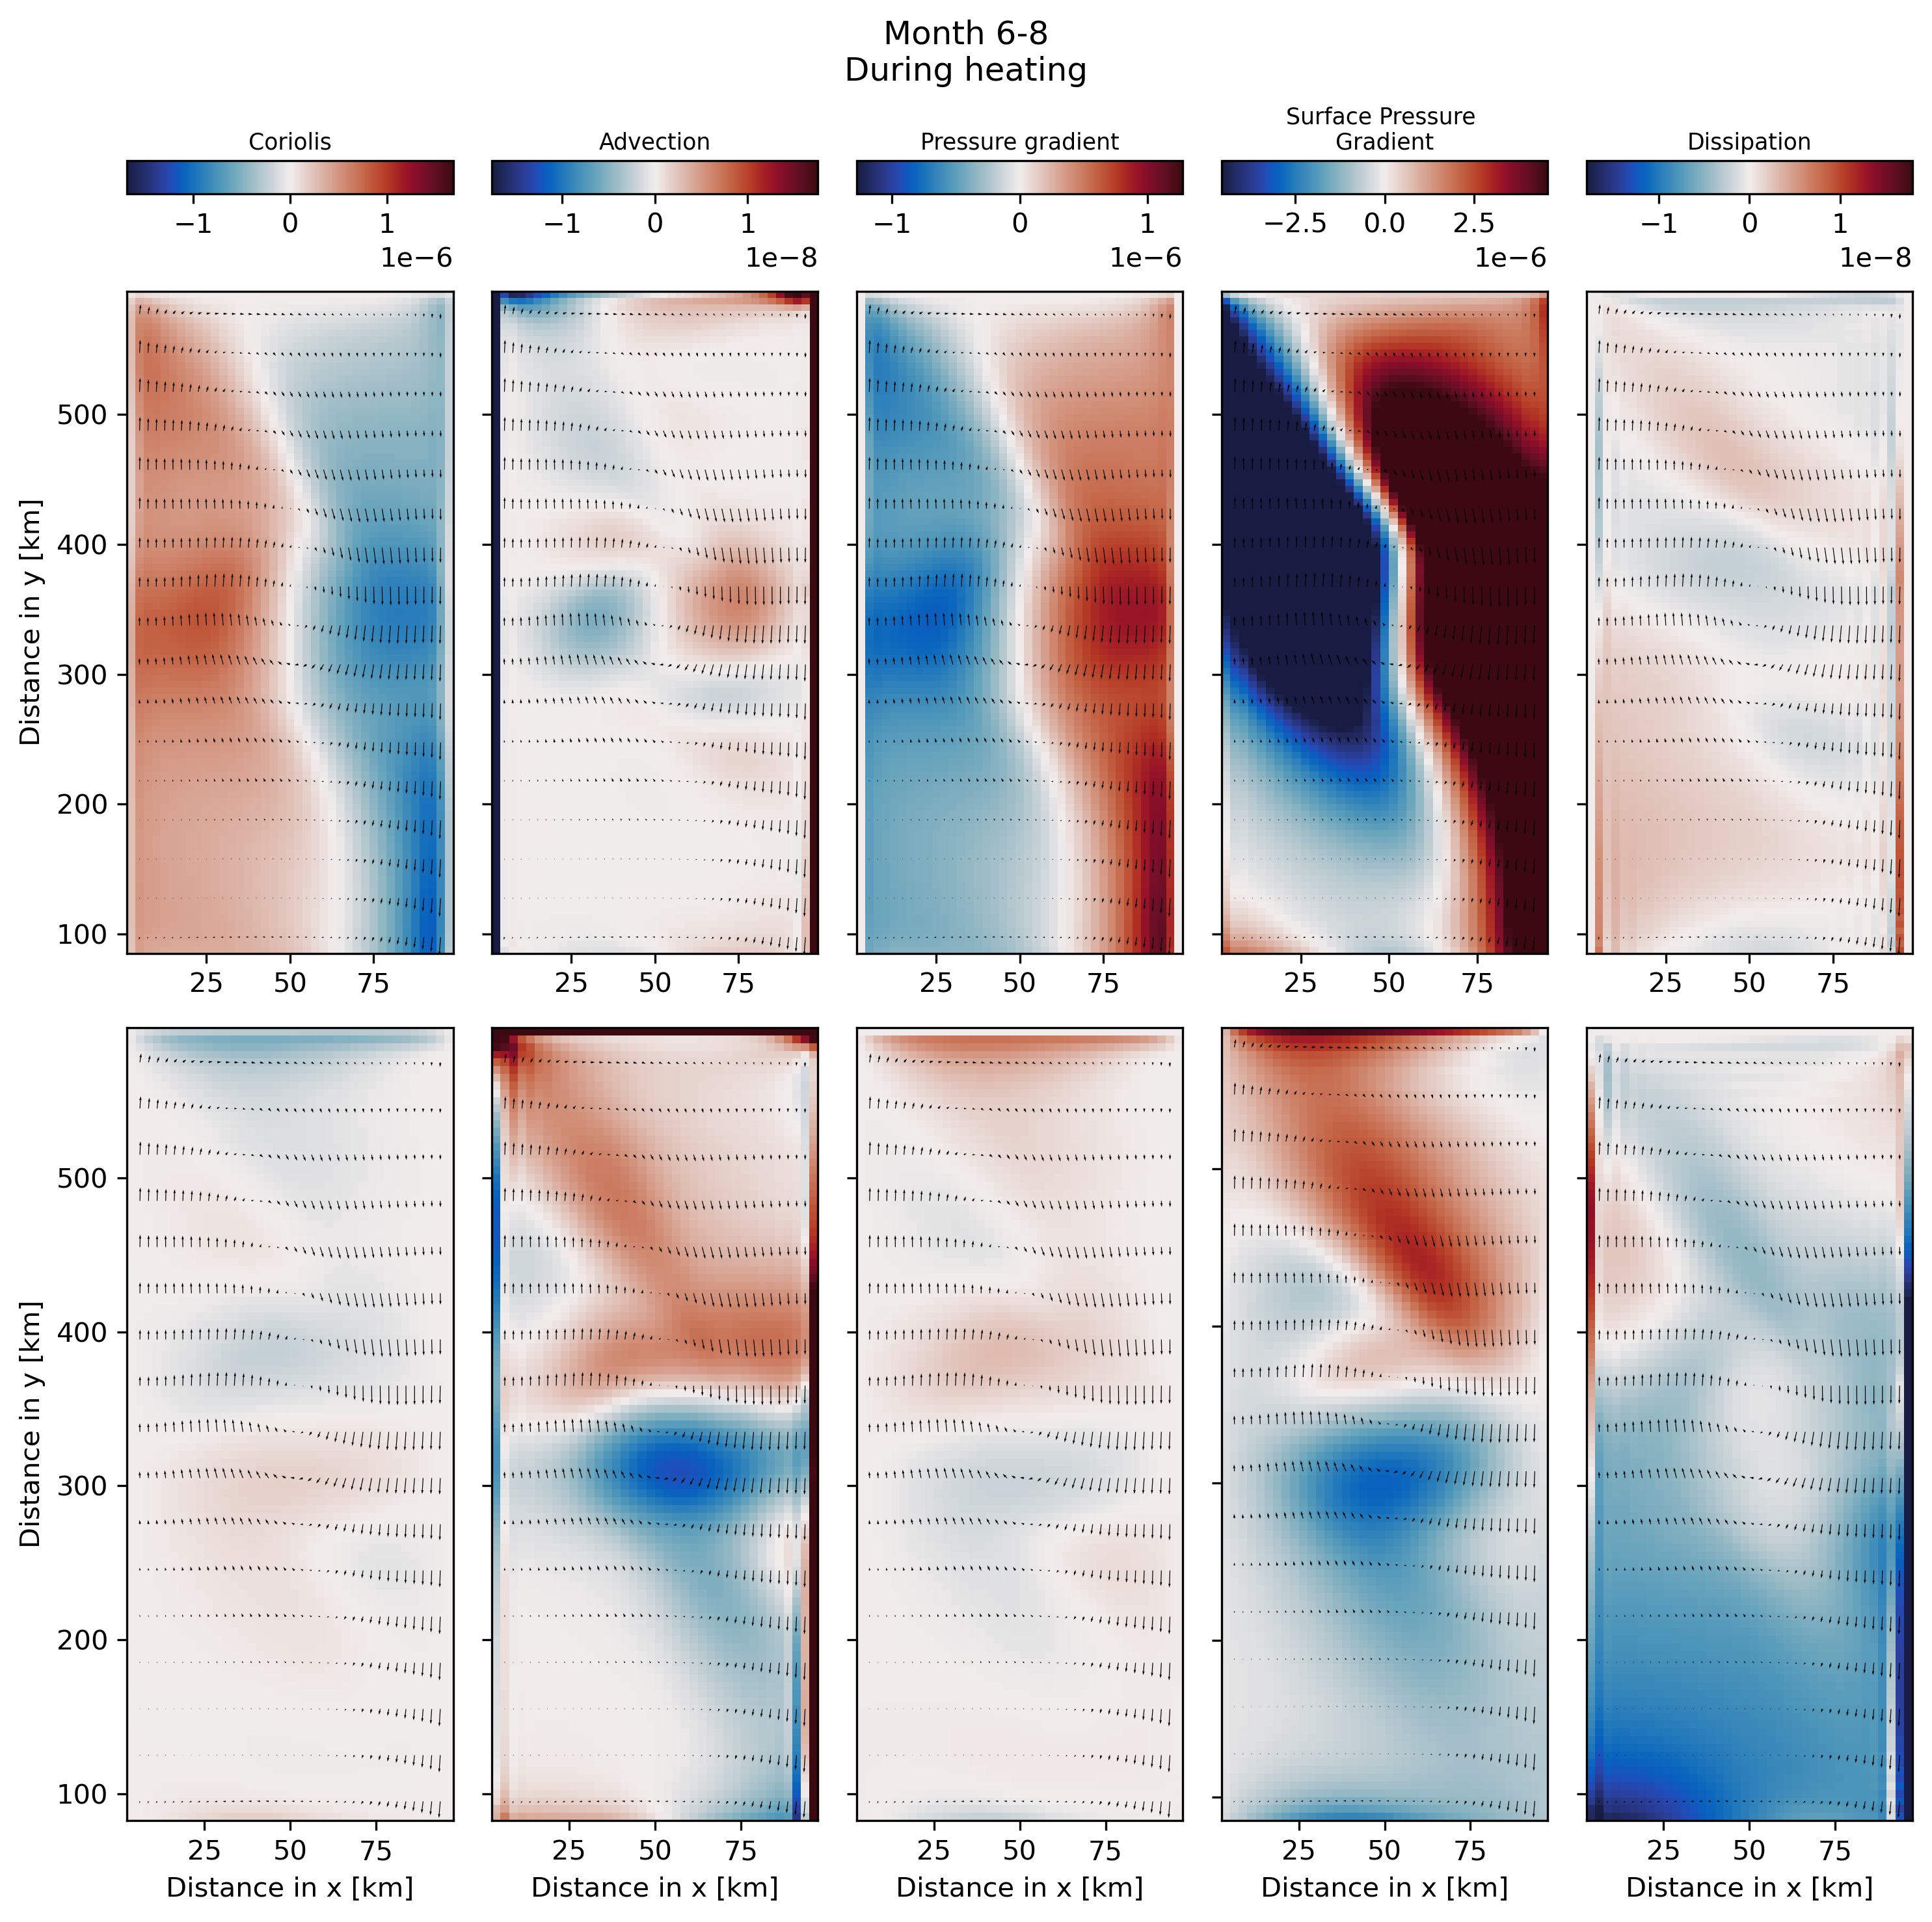

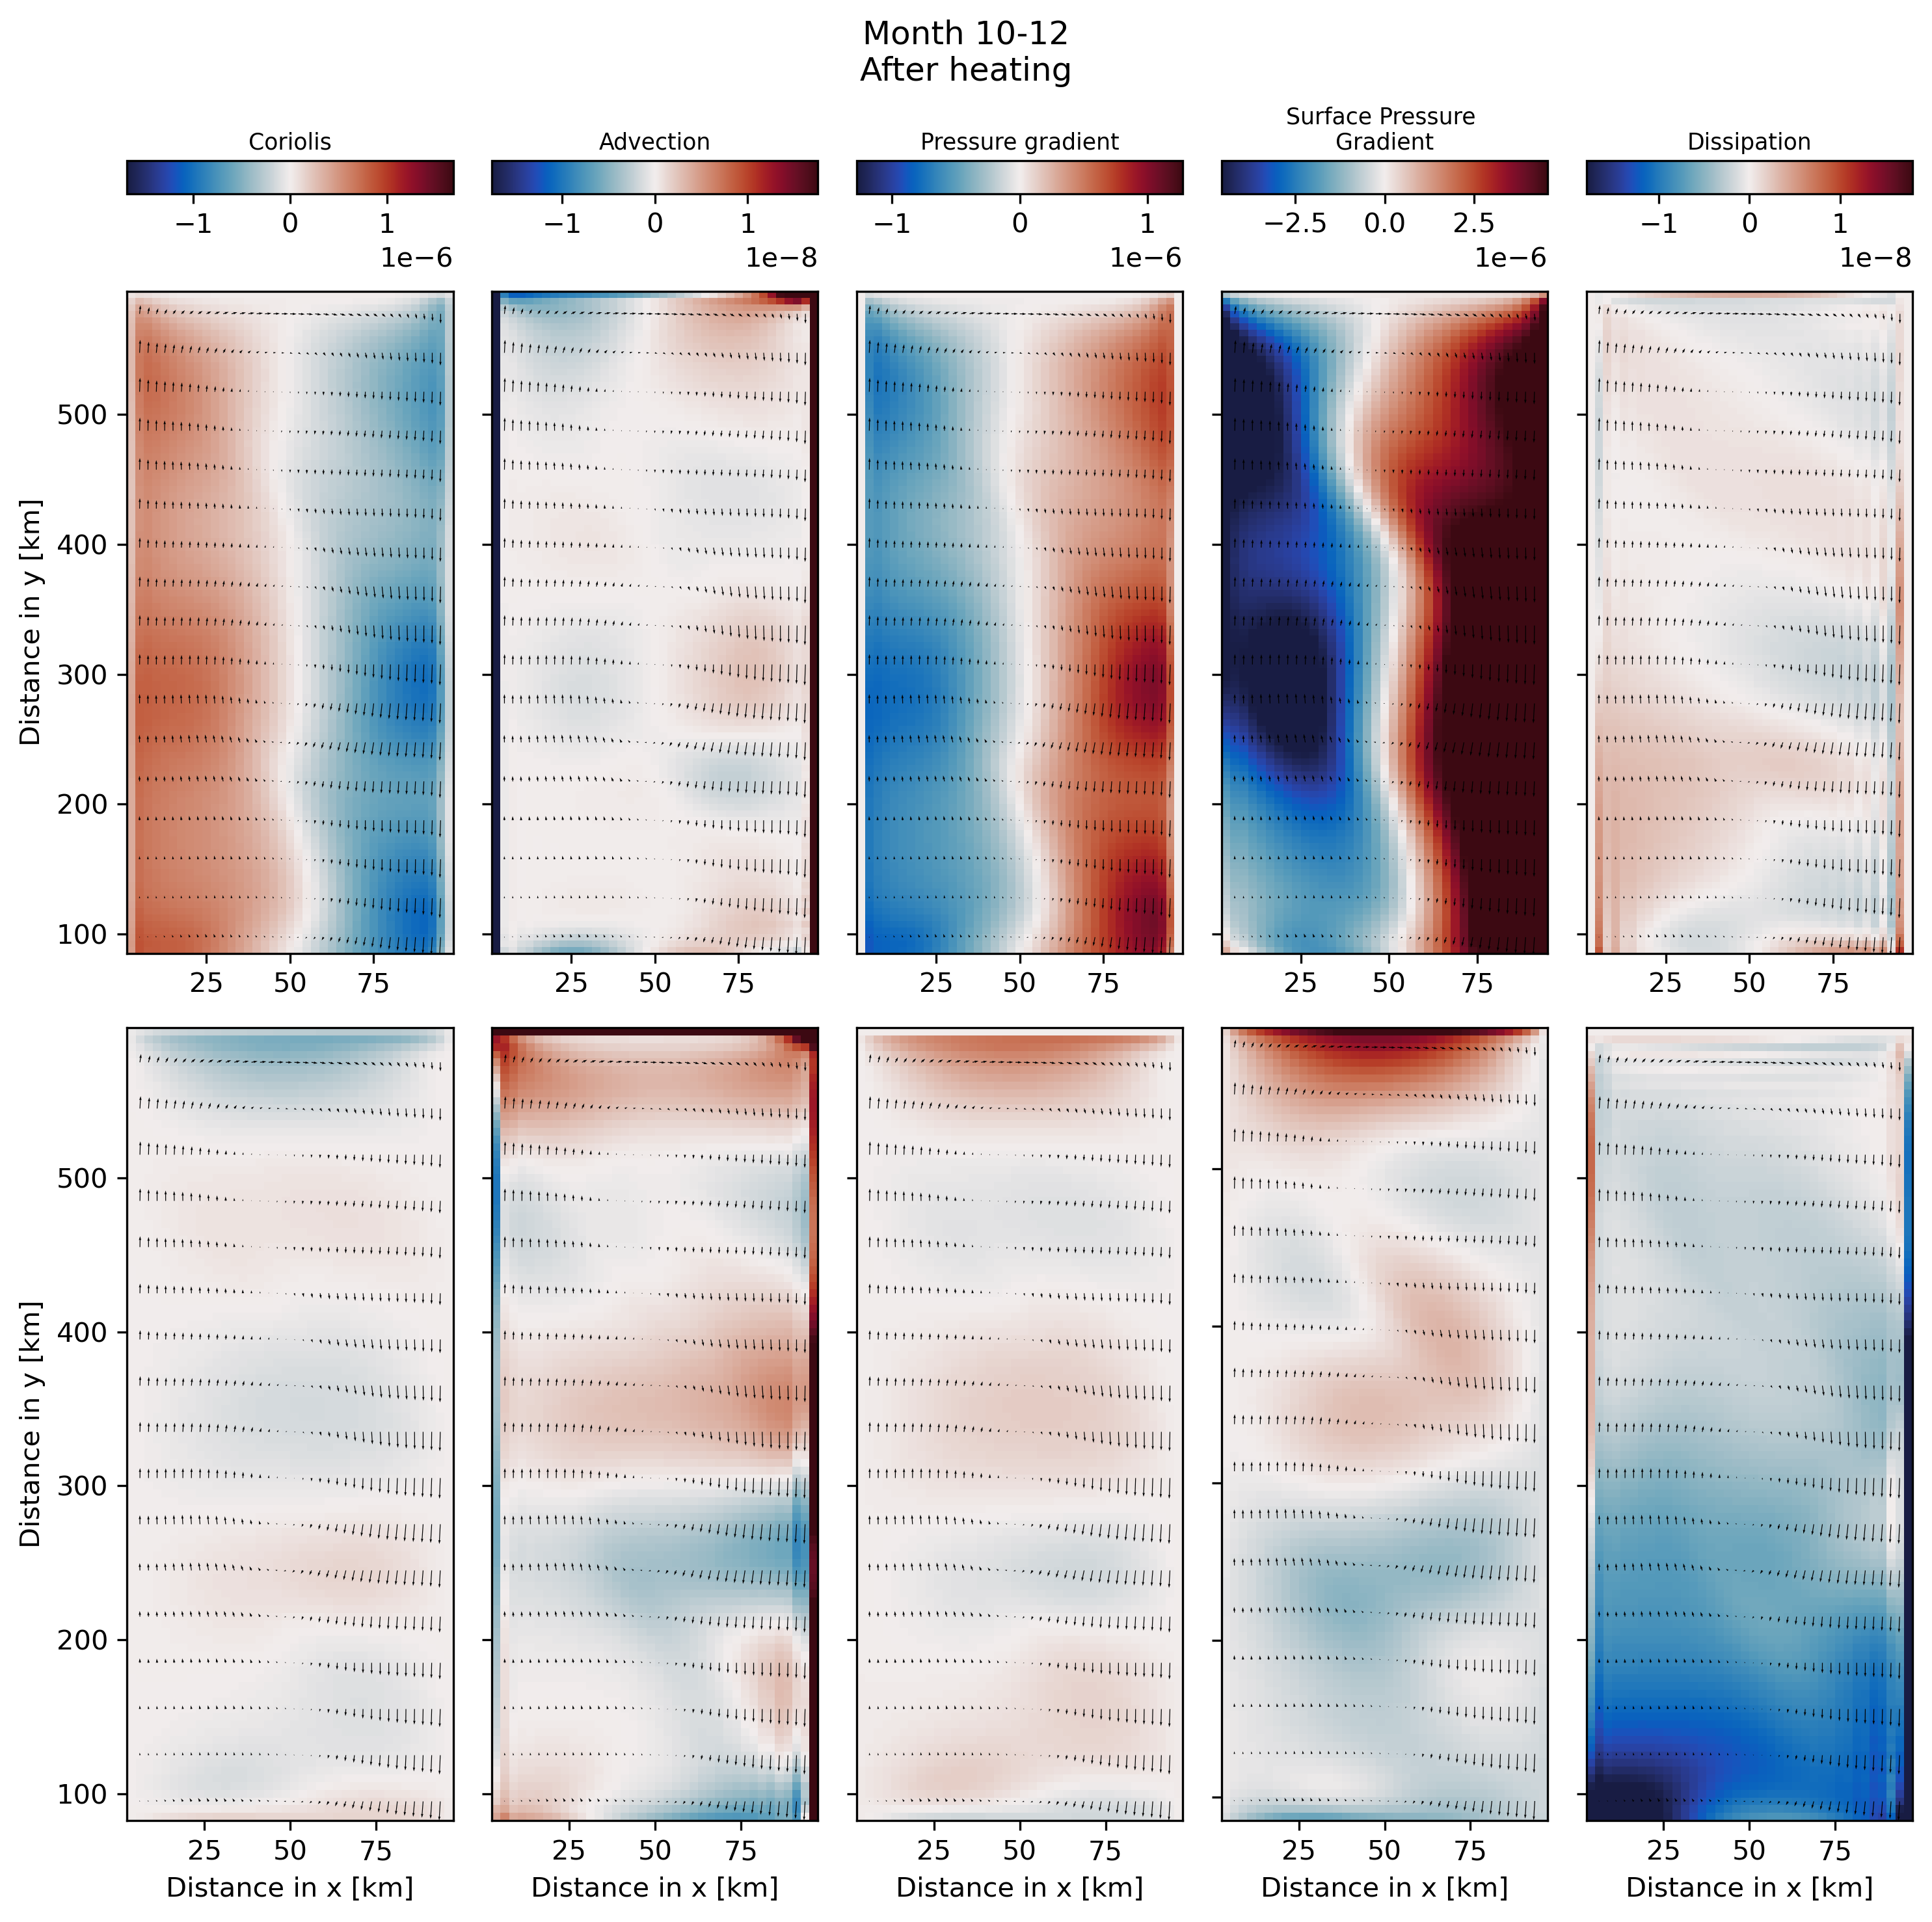

In [10]:
t=0
space=6

dep=60

VARS=[ds.Um_Cori,(ds.Um_Advec-ds.Um_Cori),ds.Um_dPhiX,dPEtaX,ds.Um_Diss,ds.Vm_Cori,(ds.Vm_Advec-ds.Vm_Cori),ds.Vm_dPhiY,dPEtaY,ds.Vm_Diss]
terms=['Coriolis','Advection','Pressure gradient', 'Surface Pressure \nGradient','Dissipation']                                                                      

o=0

vminy=[]
vmaxy=[]

for season in times:
    stitle=titles[o]
    o=o+1
    i=0
    k=0
    fig,ax=plt.subplots(2,5)
    for indivar in range(len(VARS)): #np.arange(7,len(VARS),1): #
        varin=VARS[indivar]
        cmapi=cmocean.cm.balance
        tin=season

        if indivar <= 4:
            axin=ax[0,i]
            if i==0:
                axin.set(ylabel='Distance in y [km]')
            else: 
                axin.yaxis.set_tick_params(labelleft=False)
                
            if indivar==3:
                Xin=dsS.X[:-1]
                Yin=dsS.Y[17:]
            else:
                Xin=ds.Xp1
                Yin=ds.Y[17:]
            if o==1:
                if i==4:
                    vmin=np.min(np.mean(varin[tin,:1,17:-1,2:-2],axis=1))
                    vmax=-np.min(np.mean(varin[tin,:1,17:-1,2:-2],axis=1))
                else:
                    vmin=np.min(np.mean(varin[tin,:5,17:-1,2:-2],axis=1))
                    vmax=-np.min(np.mean(varin[tin,:5,17:-1,2:-2],axis=1))
                vminy.append(vmin)
                vmaxy.append(vmax)
            else:
                vmin=vminy[i]
                vmax=vmaxy[i]
            title=terms[i]
            i=i+1
            
        elif indivar >=5:   
            axin=ax[1,k]
            axin.set(xlabel='Distance in x [km]')
            if k==0:
                axin.set(ylabel='Distance in y [km]')
            else: 
                axin.yaxis.set_tick_params(labelleft=False)
            if indivar==8:
                Xin=dsS.X
                Yin=dsS.Y[17:-1]
            else:
                Xin=ds.X
                Yin=ds.Yp1[17:]
            vmin=vminy[k]
            vmax=vmaxy[k]
            k=k+1
        

        timein=ds.T[6]/(60*60*24)
        cax=axin.pcolormesh(Xin[1:-1]/1000, Yin[:-1]/1000, np.mean(np.mean(varin[tin,:,17:-1,1:-1],axis=0),axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)


        gridY,gridX=np.meshgrid(Yin[2:-2].values,Xin[2:-2].values)

        interpV=sciint.RegularGridInterpolator((ds.Yp1[17:-1].values,ds.X[1:-1].values),np.mean(ds.VVEL[tin,0,17:-1,1:-1].values,axis=0))
        V=interpV((gridY,gridX))

        interpU=sciint.RegularGridInterpolator((ds.Y[17:-1].values,ds.Xp1[1:-1].values),np.mean(ds.UVEL[tin,0,17:-1,1:-1].values,axis=0))
        U=interpU((gridY,gridX))

        axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])
        
        if indivar <= 4:
            divider = make_axes_locatable(axin)
            axdiv = divider.new_vertical(size = '5%', pad = 0.5)
            fig.add_axes(axdiv)
            cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
            cbar_ax.ax.xaxis.set_label_position("top")
            cbar_ax.set_label(title,fontsize='small')


    
    fig.suptitle(stitle)

    fig.tight_layout()


    #plt.savefig('../' + str(project)+'/Figures/.png', bbox_inches='tight')

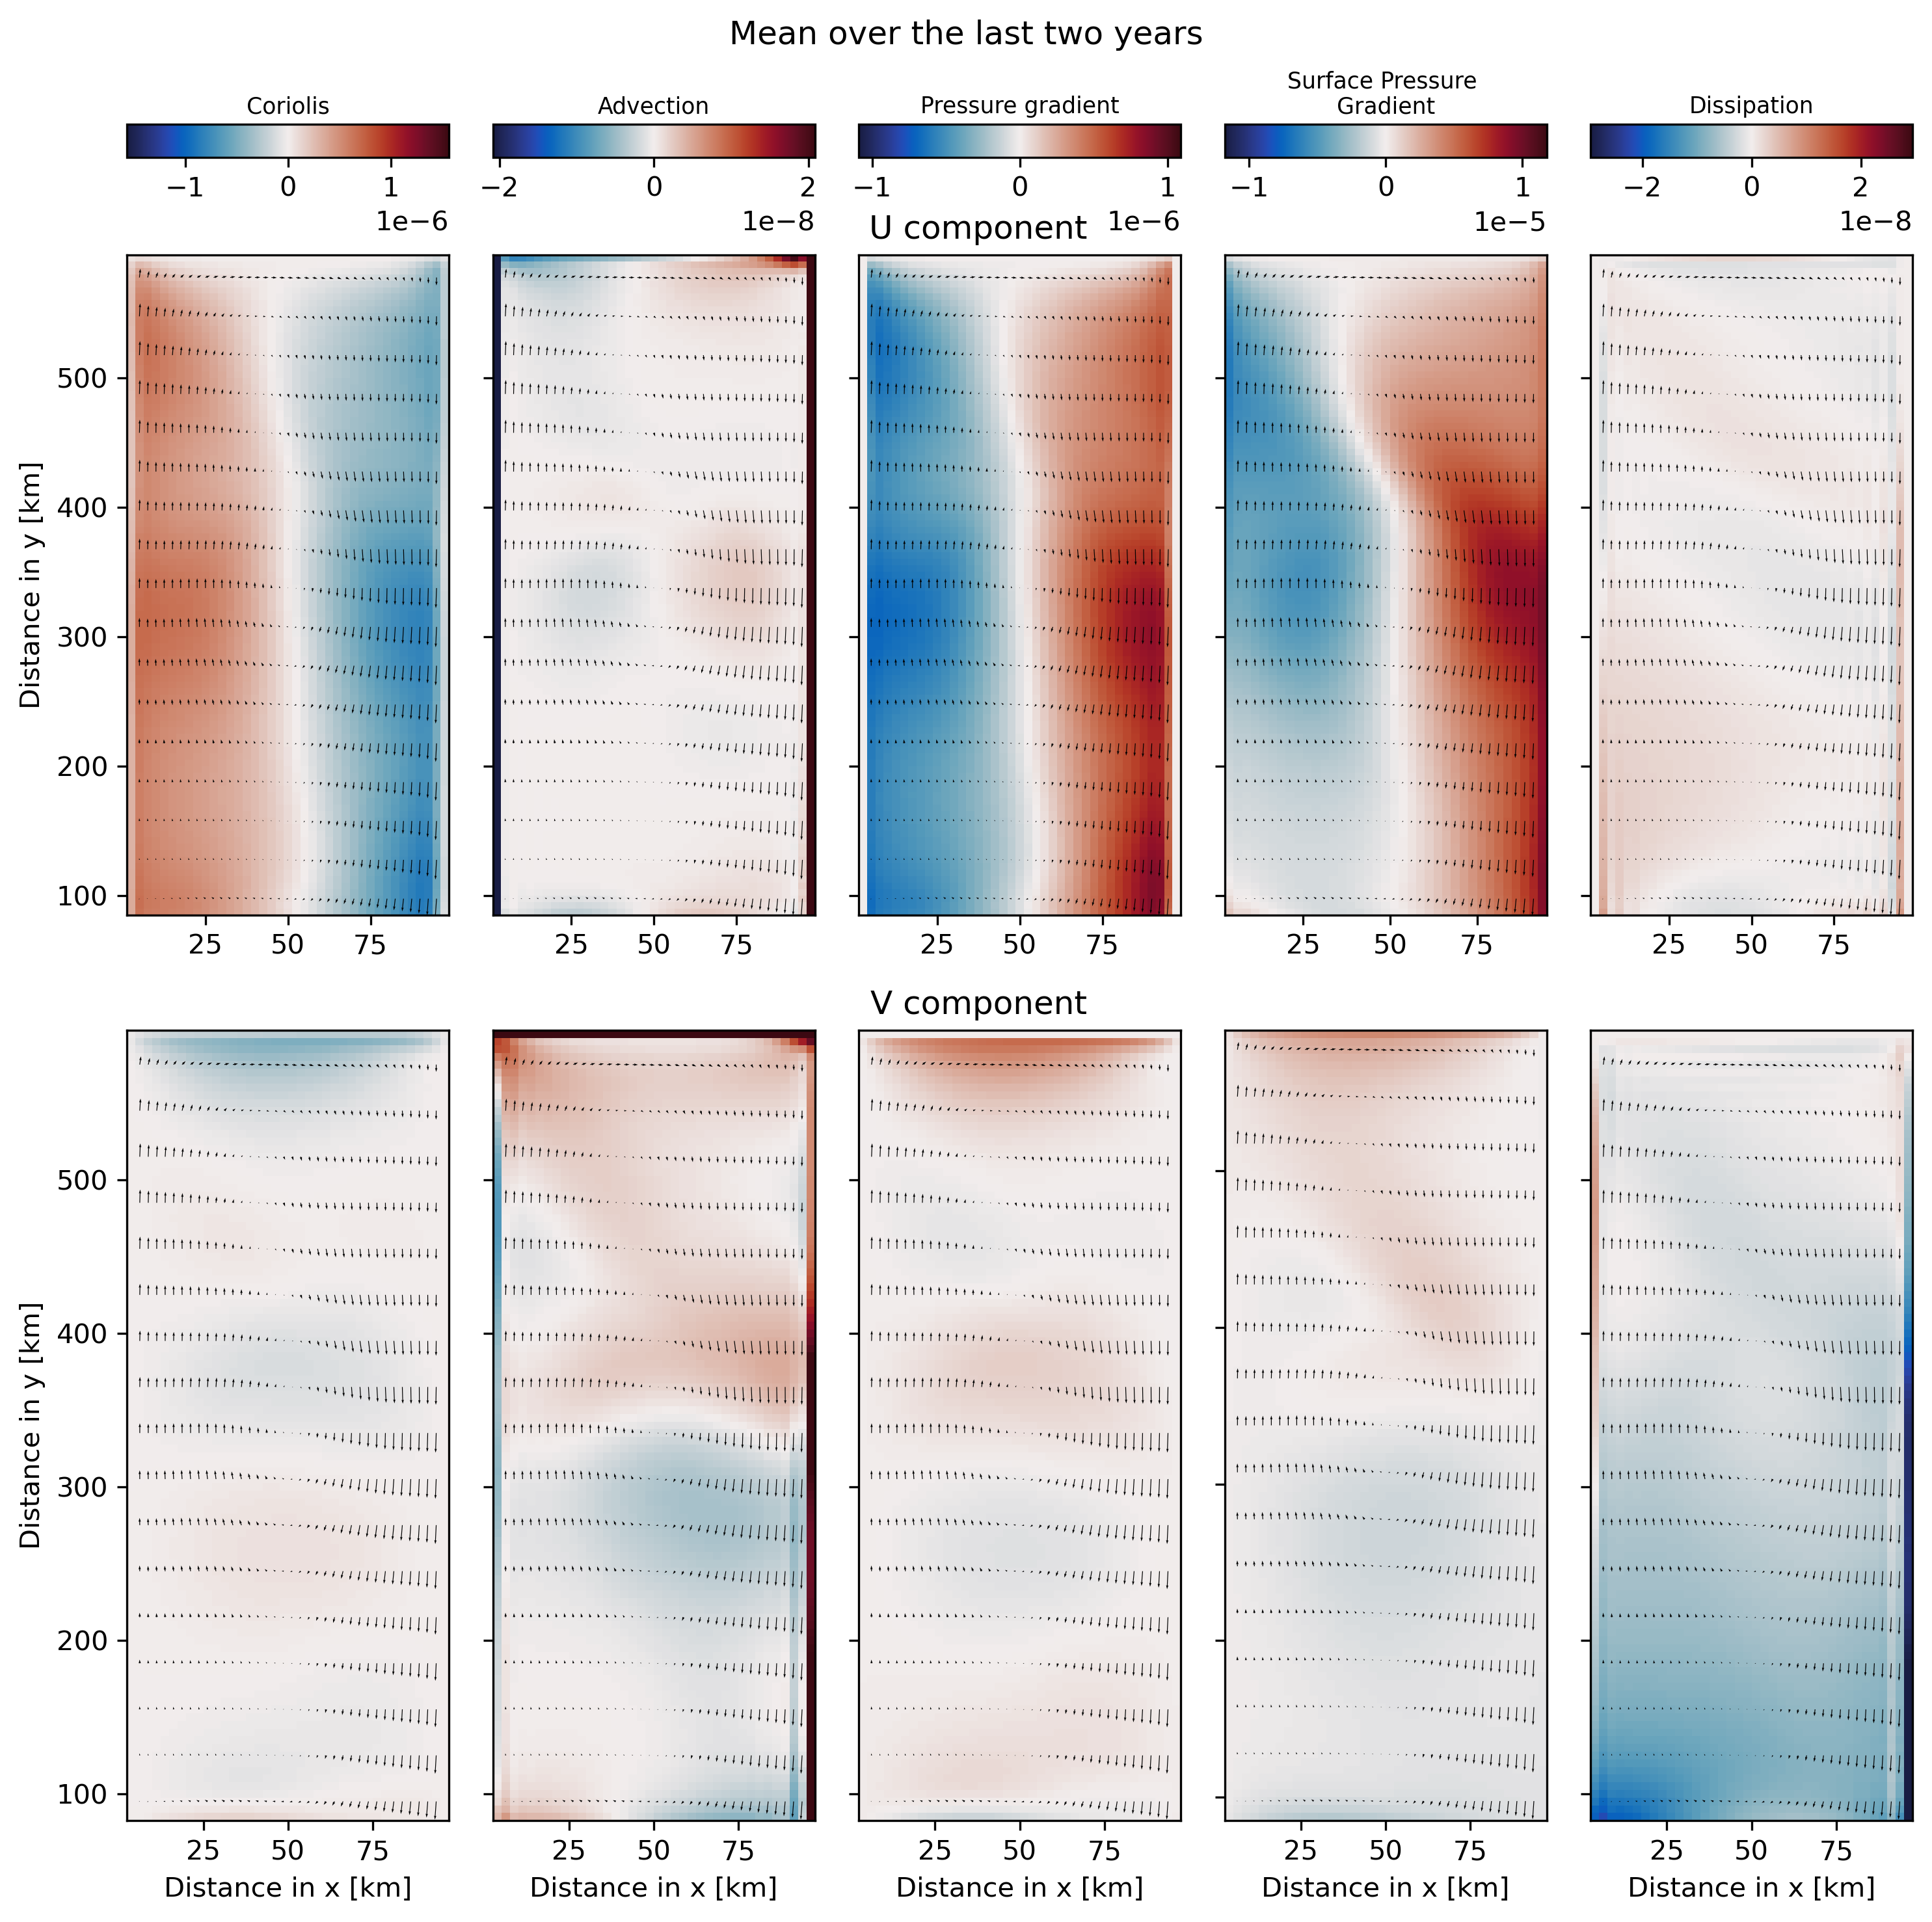

In [14]:
t=0
space=6

dep=60

VARS=[ds.Um_Cori,(ds.Um_Advec-ds.Um_Cori),ds.Um_dPhiX,dPEtaX,ds.Um_Diss,ds.Vm_Cori,(ds.Vm_Advec-ds.Vm_Cori),ds.Vm_dPhiY,dPEtaY,ds.Vm_Diss]
terms=['Coriolis','Advection','Pressure gradient', 'Surface Pressure \nGradient','Dissipation']                                                                      

o=0

vminy=[]
vmaxy=[]


o=o+1
i=0
k=0
fig,ax=plt.subplots(2,5)
for indivar in range(len(VARS)): #np.arange(7,len(VARS),1): #
    varin=VARS[indivar]
    cmapi=cmocean.cm.balance
    tin=6

    if indivar <= 4:
        axin=ax[0,i]
        if i==0:
            axin.set(ylabel='Distance in y [km]')
        else: 
            axin.yaxis.set_tick_params(labelleft=False)

        if indivar==3:
            Xin=dsS.X[:-1]
            Yin=dsS.Y[17:]
        else:
            Xin=ds.Xp1
            Yin=ds.Y[17:]
        if indivar==2:
            axin.set(title='U component        ')
        if o==1:
            if i==4:
                vmin=np.min(np.mean(varin[tin:,:1,17:-1,2:-2],axis=1))
                vmax=-np.min(np.mean(varin[tin:,:1,17:-1,2:-2],axis=1))
            else:
                vmin=np.min(np.mean(varin[tin:,:,17:-1,2:-2],axis=1))
                vmax=-np.min(np.mean(varin[tin:,:,17:-1,2:-2],axis=1))
            vminy.append(vmin)
            vmaxy.append(vmax)
        else:
            vmin=vminy[i]
            vmax=vmaxy[i]
        title=terms[i]
        i=i+1

    elif indivar >=5:   
        axin=ax[1,k]
        axin.set(xlabel='Distance in x [km]')
        if k==0:
            axin.set(ylabel='Distance in y [km]')
        else: 
            axin.yaxis.set_tick_params(labelleft=False)
        if indivar==8:
            Xin=dsS.X
            Yin=dsS.Y[17:-1]
        else:
            Xin=ds.X
            Yin=ds.Yp1[17:]
        if indivar==7:
            axin.set(title='V component        ')
        vmin=vminy[k]
        vmax=vmaxy[k]
        k=k+1


    timein=ds.T[tin]/(60*60*24)
    cax=axin.pcolormesh(Xin[1:-1]/1000, Yin[:-1]/1000, np.mean(np.mean(varin[tin:,:,17:-1,1:-1],axis=0),axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)


    gridY,gridX=np.meshgrid(Yin[2:-2].values,Xin[2:-2].values)

    interpV=sciint.RegularGridInterpolator((ds.Yp1[17:-1].values,ds.X[1:-1].values),np.mean(ds.VVEL[tin:,0,17:-1,1:-1].values,axis=0))
    V=interpV((gridY,gridX))

    interpU=sciint.RegularGridInterpolator((ds.Y[17:-1].values,ds.Xp1[1:-1].values),np.mean(ds.UVEL[tin:,0,17:-1,1:-1].values,axis=0))
    U=interpU((gridY,gridX))

    axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

    if indivar <= 4:
        divider = make_axes_locatable(axin)
        axdiv = divider.new_vertical(size = '5%', pad = 0.5)
        fig.add_axes(axdiv)
        cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
        cbar_ax.ax.xaxis.set_label_position("top")
        cbar_ax.set_label(title,fontsize='small')



fig.suptitle('Mean over the last two years')

fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/MomEq.png', bbox_inches='tight')